<a href="https://colab.research.google.com/github/adnan-math/beam_fem_ml/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import dolfinx
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" -O "/tmp/fenicsx-install.sh" && bash "/tmp/fenicsx-install.sh"
    import dolfinx

In [2]:
%cd /content
!rm -rf beam_fem_ml

!git clone https://github.com/adnan-math/beam_fem_ml.git
%cd beam_fem_ml

/content
Cloning into 'beam_fem_ml'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 53 (delta 26), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 909.38 KiB | 3.65 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/beam_fem_ml


In [3]:
!python data_generator.py

Running FEM for L = 0.70
Running FEM for L = 0.75
Running FEM for L = 0.80
Running FEM for L = 0.85
Running FEM for L = 0.90
Running FEM for L = 0.95
Running FEM for L = 1.00
Running FEM for L = 1.05
Running FEM for L = 1.10
Running FEM for L = 1.15
Running FEM for L = 1.20
Running FEM for L = 1.25
Running FEM for L = 1.30
Final dataset shape: (1300, 3)
Saved: beam_fem_dataset.csv
Saved: beam_fem_dataset.npz


In [4]:
!python training.py

X shape: (1300, 2)
y shape: (1300,)
Train samples: 1300
Interpolation test samples: 1300
Extrapolation test samples: 0
Epoch 0 | Loss = 6.620441e-01
Epoch 100 | Loss = 4.483444e-05
Epoch 200 | Loss = 9.678142e-06
Epoch 300 | Loss = 2.664298e-04
Epoch 400 | Loss = 6.220794e-06
Epoch 500 | Loss = 6.562394e-05
Epoch 600 | Loss = 8.305407e-06
Epoch 700 | Loss = 3.637508e-05
Epoch 800 | Loss = 6.913650e-06
Epoch 900 | Loss = 3.603197e-05
Model saved: beam_mlp_model.pt


In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

# ============================================================
# LOAD DATA
# ============================================================

data = np.load("beam_fem_dataset.npz")
stats = np.load("norm_stats.npz")

X = data["X"]
y = data["y"]

X_mean, X_std = stats["X_mean"], stats["X_std"]
y_mean, y_std = stats["y_mean"], stats["y_std"]

# ============================================================
# LOAD MODEL
# ============================================================

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MLP()
model.load_state_dict(torch.load("beam_mlp_model.pt"))
model.eval()

# ============================================================
# NORMALIZE INPUT
# ============================================================

Xn = (X - X_mean) / X_std

X_tensor = torch.tensor(Xn, dtype=torch.float32)

with torch.no_grad():
    pred_n = model(X_tensor).numpy().flatten()

pred = pred_n * y_std + y_mean

# ============================================================
# ERROR METRICS (INTERPOLATION / EXTRAPOLATION )
# ============================================================

L_values = np.unique(X[:, 0])

# MUST MATCH TRAINING SCRIPT
L_interp = np.array([0.8, 1.0, 1.2])

L_extrap = np.array([
    L for L in L_values
    if (L < 0.7) or (L > 1.3)
])

interp_mask = np.isin(X[:, 0], L_interp)
extrap_mask = np.isin(X[:, 0], L_extrap)

# ============================================================
# ERROR METRICS
# ============================================================

def compute_metrics(y_true, y_pred):

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    rel_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

    return mse, rmse, mae, rel_l2


mse_i, rmse_i, mae_i, rel_i = compute_metrics(y[interp_mask],pred[interp_mask])
print("\nINTERPOLATION")
print("MSE :", mse_i)
print("RMSE:", rmse_i)
print("MAE :", mae_i)
print("Rel L2:", rel_i)


mse_e, rmse_e, mae_e, rel_e = compute_metrics(y[extrap_mask],pred[extrap_mask])
print("\nEXTRAPOLATION")
print("MSE :", mse_e)
print("RMSE:", rmse_e)
print("MAE :", mae_e)
print("Rel L2:", rel_e)



# ============================================================
# ERROR CURVES PER LENGTH
# ============================================================

for L in L_values:
    mask = np.isclose(X[:, 0], L)

    err = np.mean(np.abs(y[mask] - pred[mask]))
    print(f"L = {L:.3f} | MAE = {err:.6e}")


INTERPOLATION
MSE : 1.2384415728777159e-18
RMSE: 1.1128528981306182e-09
MAE : 9.079735748393195e-10
Rel L2: 0.001068580918605567

EXTRAPOLATION
MSE : nan
RMSE: nan
MAE : nan
Rel L2: nan
L = 0.700 | MAE = 5.606586e-10
L = 0.750 | MAE = 5.236661e-10
L = 0.800 | MAE = 5.501182e-10
L = 0.850 | MAE = 5.078943e-10
L = 0.900 | MAE = 6.077715e-10
L = 0.950 | MAE = 6.309864e-10
L = 1.000 | MAE = 9.079736e-10
L = 1.050 | MAE = 7.110130e-10
L = 1.100 | MAE = 6.355114e-10
L = 1.150 | MAE = 7.299746e-10
L = 1.200 | MAE = 9.330382e-10
L = 1.250 | MAE = 9.747900e-10
L = 1.300 | MAE = 9.829161e-10


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3806/1999856212.py:82: RuntimeWarning: invalid value encountered in scalar divide
  rel_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)


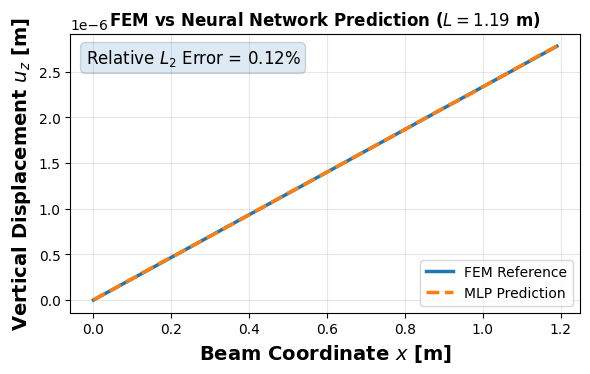

In [23]:
# ============================================================
# FEM vs NN (INTERPOLATION - RUNTIME FEM GENERATION)
# ============================================================

from fem_dataset import BeamDataset
import numpy as np
import matplotlib.pyplot as plt
import torch

# create FEM generator object
dataset = BeamDataset()

# choose unseen interpolation value
L_plot = 1.19

# ============================================================
# GENERATE FEM SOLUTION ON THE FLY
# ============================================================

data_L = dataset.generate(L_plot, n_points=100)

x = data_L[:, 1]
y_true = data_L[:, 2]

# ============================================================
# NN PREDICTION
# ============================================================

L_array = np.full_like(x, L_plot)

X_nn = np.stack([L_array, x], axis=1)

# normalize
X_nn = (X_nn - X_mean) / X_std

X_tensor = torch.tensor(X_nn, dtype=torch.float32)

with torch.no_grad():
    y_pred_n = model(X_tensor).numpy().flatten()

# denormalize
y_pred = y_pred_n * y_std + y_mean

# ============================================================
# SORT FOR PLOTTING
# ============================================================

idx = np.argsort(x)
x = x[idx]
y_true = y_true[idx]
y_pred = y_pred[idx]

# ============================================================
# ERROR
# ============================================================

rel_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

# ============================================================
# PLOT
# ============================================================
# ============================================================
# FEM vs Neural Network Surrogate
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    x,
    y_true,
    linewidth=2.5,
    label="FEM Reference"
)

plt.plot(
    x,
    y_pred,
    "--",
    linewidth=2.5,
    label="MLP Prediction"
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(
    r"Beam Coordinate $x$ [m]",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    r"Vertical Displacement $u_z$ [m]",
    fontsize=14,
    fontweight="bold"
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(
    rf"FEM vs Neural Network Prediction ($L = {L_plot:.2f}$ m)",
    fontsize=12,
    fontweight="bold"
)

# ------------------------------------------------------------
# Error annotation
# ------------------------------------------------------------

plt.text(
    0.03,
    0.95,
    rf"Relative $L_2$ Error = {100*rel_l2:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

plt.grid(True, alpha=0.3)

plt.legend(
    fontsize=10,
    frameon=True
)

plt.tick_params(
    axis="both",
    labelsize=10
)

plt.tight_layout()

# High-quality export for Beamer
plt.savefig(
    "fem_vs_nn_L140.pdf",
    bbox_inches="tight"
)

plt.show()

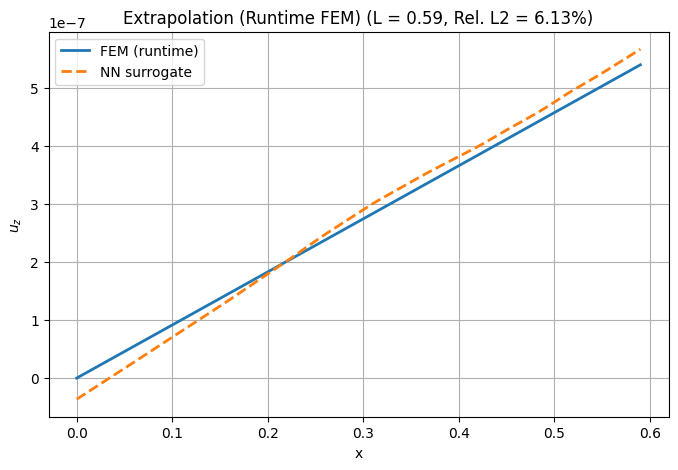

In [19]:
# ============================================================
# FEM vs NN (INTERPOLATION - RUNTIME FEM GENERATION)
# ============================================================

from fem_dataset import BeamDataset
import numpy as np
import matplotlib.pyplot as plt
import torch

# create FEM generator object
dataset = BeamDataset()

# choose unseen interpolation value
L_plot = 0.59

# ============================================================
# GENERATE FEM SOLUTION ON THE FLY
# ============================================================

data_L = dataset.generate(L_plot, n_points=100)

x = data_L[:, 1]
y_true = data_L[:, 2]

# ============================================================
# NN PREDICTION
# ============================================================

L_array = np.full_like(x, L_plot)

X_nn = np.stack([L_array, x], axis=1)

# normalize
X_nn = (X_nn - X_mean) / X_std

X_tensor = torch.tensor(X_nn, dtype=torch.float32)

with torch.no_grad():
    y_pred_n = model(X_tensor).numpy().flatten()

# denormalize
y_pred = y_pred_n * y_std + y_mean

# ============================================================
# SORT FOR PLOTTING
# ============================================================

idx = np.argsort(x)
x = x[idx]
y_true = y_true[idx]
y_pred = y_pred[idx]

# ============================================================
# ERROR
# ============================================================

rel_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(x, y_true, label="FEM (runtime)", linewidth=2)
plt.plot(x, y_pred, "--", label="NN surrogate", linewidth=2)

plt.xlabel("x")
plt.ylabel(r"$u_z$")
plt.title(
    f"Extrapolation (Runtime FEM) "
    f"(L = {L_plot:.2f}, Rel. L2 = {100*rel_l2:.2f}%)"
)

plt.legend()
plt.grid()
plt.show()

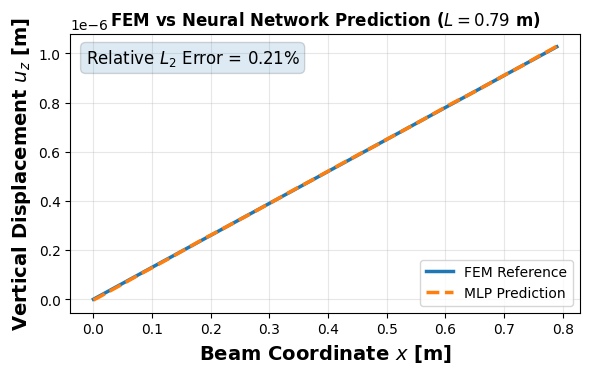

In [22]:
# ============================================================
# FEM vs Neural Network Surrogate
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    x,
    y_true,
    linewidth=2.5,
    label="FEM Reference"
)

plt.plot(
    x,
    y_pred,
    "--",
    linewidth=2.5,
    label="MLP Prediction"
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(
    r"Beam Coordinate $x$ [m]",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    r"Vertical Displacement $u_z$ [m]",
    fontsize=14,
    fontweight="bold"
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(
    rf"FEM vs Neural Network Prediction ($L = {L_plot:.2f}$ m)",
    fontsize=12,
    fontweight="bold"
)

# ------------------------------------------------------------
# Error annotation
# ------------------------------------------------------------

plt.text(
    0.03,
    0.95,
    rf"Relative $L_2$ Error = {100*rel_l2:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

plt.grid(True, alpha=0.3)

plt.legend(
    fontsize=10,
    frameon=True
)

plt.tick_params(
    axis="both",
    labelsize=10
)

plt.tight_layout()

# High-quality export for Beamer
plt.savefig(
    "fem_vs_nn_L140.pdf",
    bbox_inches="tight"
)

plt.show()

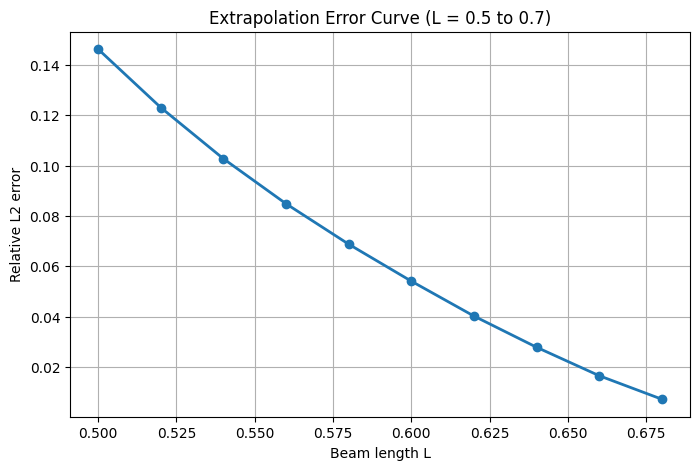

In [7]:
from fem_dataset import BeamDataset
import numpy as np
import matplotlib.pyplot as plt
import torch

dataset = BeamDataset()

# ============================================================
# EXTRAPOLATION RANGE
# ============================================================

L_extrap_curve = np.arange(0.5, 0.7, 0.02)

rel_l2_errors = []

# ============================================================
# LOOP OVER L VALUES
# ============================================================

for L_plot in L_extrap_curve:

    # -----------------------------
    # FEM solution (ground truth)
    # -----------------------------
    data_L = dataset.generate(L_plot, n_points=100)

    x = data_L[:, 1]
    y_true = data_L[:, 2]

    # -----------------------------
    # NN prediction
    # -----------------------------
    L_array = np.full_like(x, L_plot)

    X_nn = np.stack([L_array, x], axis=1)

    X_nn = (X_nn - X_mean) / X_std

    X_tensor = torch.tensor(X_nn, dtype=torch.float32)

    with torch.no_grad():
        y_pred_n = model(X_tensor).numpy().flatten()

    y_pred = y_pred_n * y_std + y_mean

    # -----------------------------
    # error
    # -----------------------------
    rel_l2 = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

    rel_l2_errors.append(rel_l2)

# ============================================================
# PLOT ERROR CURVE
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(L_extrap_curve, rel_l2_errors, marker='o', linewidth=2)

plt.xlabel("Beam length L")
plt.ylabel("Relative L2 error")
plt.title("Extrapolation Error Curve (L = 0.5 to 0.7)")
plt.grid()
plt.show()

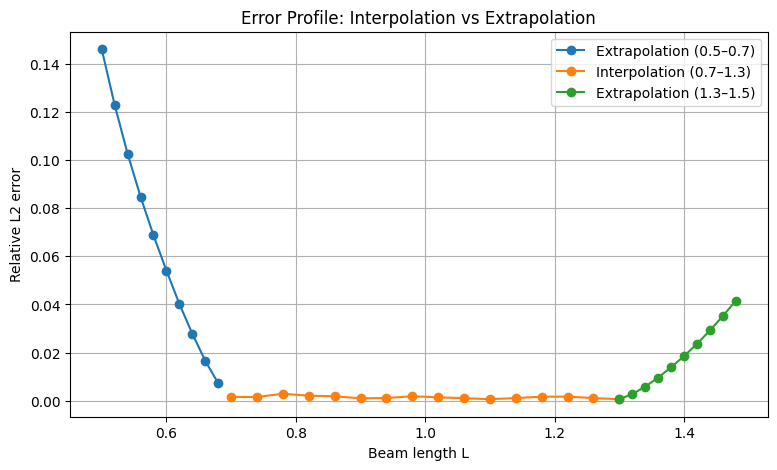

In [8]:
from fem_dataset import BeamDataset
import numpy as np
import matplotlib.pyplot as plt
import torch

dataset = BeamDataset()

# ============================================================
# L RANGES
# ============================================================

L_extrap_left  = np.arange(0.5, 0.7, 0.02)
L_interp       = np.arange(0.7, 1.3, 0.04)
L_extrap_right = np.arange(1.3, 1.5, 0.02)

# ============================================================
# STORAGE
# ============================================================

err_left = []
err_interp = []
err_right = []

# ============================================================
# ERROR FUNCTION
# ============================================================

def compute_rel_l2(L_plot):

    data_L = dataset.generate(L_plot, n_points=100)

    x = data_L[:, 1]
    y_true = data_L[:, 2]

    L_array = np.full_like(x, L_plot)
    X_nn = np.stack([L_array, x], axis=1)

    X_nn = (X_nn - X_mean) / X_std

    X_tensor = torch.tensor(X_nn, dtype=torch.float32)

    with torch.no_grad():
        y_pred_n = model(X_tensor).numpy().flatten()

    y_pred = y_pred_n * y_std + y_mean

    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

# ============================================================
# LEFT EXTRAPOLATION
# ============================================================

for L in L_extrap_left:
    err_left.append(compute_rel_l2(L))

# ============================================================
# INTERPOLATION
# ============================================================

for L in L_interp:
    err_interp.append(compute_rel_l2(L))

# ============================================================
# RIGHT EXTRAPOLATION
# ============================================================

for L in L_extrap_right:
    err_right.append(compute_rel_l2(L))

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9,5))

plt.plot(L_extrap_left, err_left, marker='o', label="Extrapolation (0.5–0.7)")
plt.plot(L_interp, err_interp, marker='o', label="Interpolation (0.7–1.3)")
plt.plot(L_extrap_right, err_right, marker='o', label="Extrapolation (1.3–1.5)")

plt.xlabel("Beam length L")
plt.ylabel("Relative L2 error")
plt.title("Error Profile: Interpolation vs Extrapolation")
plt.legend()
plt.grid()
plt.show()

In [37]:
#L_extrap_right = np.delete(L_extrap_right, 0)
#err_right = np.delete(err_right,0)
L_interp

array([0.7 , 0.74, 0.78, 0.82, 0.86, 0.9 , 0.94, 0.98, 1.02, 1.06, 1.1 ,
       1.14, 1.18, 1.22, 1.26, 1.3 ])

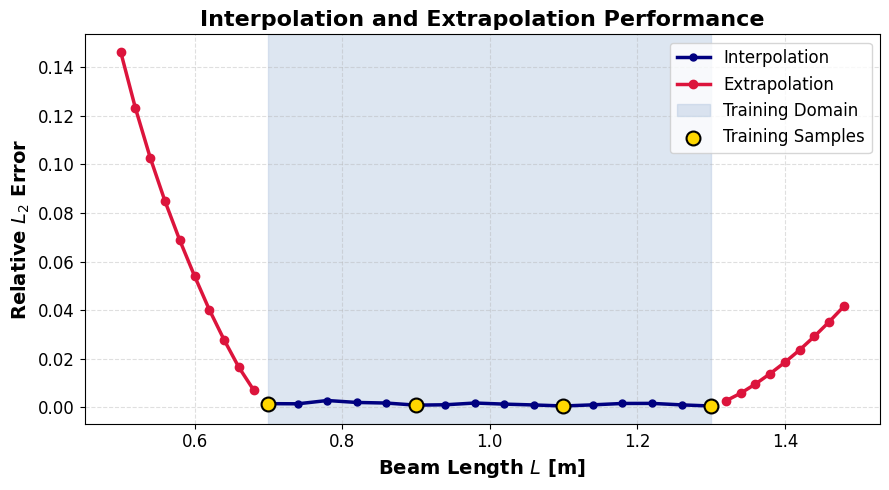

In [42]:
# ============================================================
# PUBLICATION-STYLE ERROR PLOT (WITH TRAINING POINTS)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

# ------------------------------------------------------------
# Interpolation region (within training domain)
# ------------------------------------------------------------

plt.plot(
    L_interp,
    err_interp,
    linewidth=2.5,
    marker="o",
    markersize=5,
    color="navy",
    label="Interpolation"
)

# ------------------------------------------------------------
# Extrapolation (left)
# ------------------------------------------------------------

plt.plot(
    L_extrap_left,
    err_left,
    linewidth=2.5,
    marker="o",
    markersize=6,
    color="crimson",
    label="Extrapolation"
)

# ------------------------------------------------------------
# Extrapolation (right)
# ------------------------------------------------------------

plt.plot(
    L_extrap_right,
    err_right,
    linewidth=2.5,
    marker="o",
    markersize=6,
    color="crimson"
)

# ------------------------------------------------------------
# Training domain shading
# ------------------------------------------------------------

plt.axvspan(
    0.7,
    1.3,
    alpha=0.42,
    color="lightsteelblue",
    label="Training Domain"
)

# ------------------------------------------------------------
# Highlight training points inside interpolation set
# ------------------------------------------------------------

train_points = np.array([0.7, 0.9, 1.1, 1.3])

train_mask = np.isclose(
    L_interp[:, None],
    train_points[None, :],
    atol=1e-8
).any(axis=1)

plt.scatter(
    L_interp[train_mask],
    np.array(err_interp)[train_mask],
    s=100,
    color="gold",
    edgecolors="black",
    linewidths=1.5,
    zorder=3,
    label="Training Samples"
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(
    r"Beam Length $L$ [m]",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    r"Relative $L_2$ Error",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Interpolation and Extrapolation Performance",
    fontsize=16,
    fontweight="bold"
)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend(
    fontsize=12,
    frameon=True
)

plt.tight_layout()

plt.savefig(
    "error_profile.pdf",
    bbox_inches="tight"
)

plt.show()

In [9]:
import numpy as np
import pyvista as pv
import imageio
from dolfinx import fem, plot
from fem_dataset import BeamDataset

# ============================================================
# DATASET
# ============================================================

dataset = BeamDataset()

# ============================================================
# PARAMETERS
# ============================================================

L_values = np.linspace(0.5, 1.5, 50)

warp_factor = 8000

fps = 5

# ============================================================
# USE LARGEST BEAM FOR REFERENCE FRAME
# ============================================================

L_ref = np.max(L_values)

domain, V_ref, uh_ref = dataset.solve(
    L_ref,
    dataset.traction
)

topology_ref, cell_types_ref, geom_ref = plot.vtk_mesh(V_ref)

# ------------------------------------------------------------
# LEFT END ALWAYS AT x = 0
# ------------------------------------------------------------

geom_ref = geom_ref.copy()
geom_ref[:, 0] -= geom_ref[:, 0].min()

grid_ref = pv.UnstructuredGrid(
    topology_ref,
    cell_types_ref,
    geom_ref.copy()
)

# ============================================================
# PLOTTER
# ============================================================

p = pv.Plotter(
    off_screen=True,
    window_size=(1400, 700)
)

# ------------------------------------------------------------
# REFERENCE MESH
# ------------------------------------------------------------

p.add_mesh(
    grid_ref,
    style="wireframe",
    color="black",
    opacity=0.15
)

# ============================================================
# TEXT
# ============================================================

label_actor = p.add_text(
    "",
    position="upper_left",
    font_size=14,
    color="black"
)

# ============================================================
# CAMERA (BASED ON LARGEST BEAM)
# ============================================================

bounds = grid_ref.bounds

xmin, xmax = bounds[0], bounds[1]
ymin, ymax = bounds[2], bounds[3]
zmin, zmax = bounds[4], bounds[5]

xc = 0.5 * (xmin + xmax)
yc = 0.5 * (ymin + ymax)
zc = 0.5 * (zmin + zmax)

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin

camera_position = (
    xc,
    yc + 6.0 * dy,
    zc + 2.0 * dz
)

p.camera_position = [
    camera_position,
    (xc, yc, zc),
    (0, 0, 1)
]

p.enable_parallel_projection()

p.camera.zoom(0.6)

p.reset_camera_clipping_range()

# ============================================================
# WHITE BACKGROUND
# ============================================================

for renderer in p.renderers:
    renderer.SetBackground(1, 1, 1)

# ============================================================
# PRECOMPUTE ALL FEM SOLUTIONS
# ============================================================

solutions = []
all_uz = []

print("\nPrecomputing FEM solutions...\n")

for L in L_values:

    domain, V, uh = dataset.solve(
        L,
        dataset.traction
    )

    u_interp = fem.Function(V)
    u_interp.interpolate(uh)

    u = u_interp.x.array.reshape(-1, 3)

    # downward displacement positive
    uz = -u[:, 2]
    solutions.append((L, V, uz ) )
    all_uz.append(uz)

all_uz = np.concatenate(all_uz)

vmin = all_uz.min()
vmax = all_uz.max()


# ============================================================
# ANIMATION LOOP
# ============================================================

frames = []

mesh_actor = None

for L, V, uz in solutions:

    print(
        f"L = {L:.3f}"
    )

    topology, cell_types, geom = plot.vtk_mesh(V)

    # --------------------------------------------------------
    # FIX LEFT END AT x = 0
    # --------------------------------------------------------

    geom = geom.copy()

    geom[:, 0] -= geom[:, 0].min()

    # --------------------------------------------------------
    # BUILD GRID
    # --------------------------------------------------------

    grid = pv.UnstructuredGrid(topology, cell_types,geom)
    grid.point_data["u"] = uz

    # --------------------------------------------------------
    # WARP
    # --------------------------------------------------------

    warped = grid.warp_by_scalar(
        "u",
        factor=warp_factor
    )

    # --------------------------------------------------------
    # REMOVE PREVIOUS ACTOR
    # --------------------------------------------------------

    if mesh_actor is not None:
        p.remove_actor(mesh_actor)

    # --------------------------------------------------------
    # ADD CURRENT FRAME
    # --------------------------------------------------------

    mesh_actor = p.add_mesh(
        warped,
        scalars="u",
        cmap="viridis",
        clim=[vmin, vmax],
        show_scalar_bar=True,
        scalar_bar_args={
            "title": "Displacement $u_z$",
            "vertical": True,
            "height": 0.70,
            "position_x": 0.85,
            "position_y": 0.15,
            "title_font_size": 14,
            "label_font_size": 12,
        }
    )

    # --------------------------------------------------------
    # UPDATE LABEL
    # --------------------------------------------------------

    label_actor.SetText(
        0,
        f"L = {L:.3f}    |    Warp = {warp_factor}"
    )

    # --------------------------------------------------------
    # RENDER
    # --------------------------------------------------------

    p.render()

    frame = p.screenshot(
        None,
        return_img=True
    )

    frames.append(frame)

# ============================================================
# EXPORT
# ============================================================

imageio.mimsave(
    "beam_L_animation.gif",
    frames,
    fps=fps
)

imageio.mimsave(
    "beam_L_animation.mp4",
    frames,
    fps=fps
)

print("\nSaved:")
print("beam_L_animation.gif")
print("beam_L_animation.mp4")


Precomputing FEM solutions...

L = 0.500
L = 0.520
L = 0.541
L = 0.561
L = 0.582
L = 0.602
L = 0.622
L = 0.643
L = 0.663
L = 0.684
L = 0.704
L = 0.724
L = 0.745
L = 0.765
L = 0.786
L = 0.806
L = 0.827
L = 0.847
L = 0.867
L = 0.888
L = 0.908
L = 0.929
L = 0.949
L = 0.969
L = 0.990
L = 1.010
L = 1.031
L = 1.051
L = 1.071
L = 1.092
L = 1.112
L = 1.133
L = 1.153
L = 1.173
L = 1.194
L = 1.214
L = 1.235
L = 1.255
L = 1.276
L = 1.296
L = 1.316
L = 1.337
L = 1.357
L = 1.378
L = 1.398
L = 1.418
L = 1.439
L = 1.459
L = 1.480
L = 1.500



Saved:
beam_L_animation.gif
beam_L_animation.mp4
